<a href="https://colab.research.google.com/github/adn26/LinearRegressionMuLearn/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Packages Required**

In [24]:
# data handling packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# torch packages
import torch
import torch.nn as nn
import torch.optim as optim

# scikit learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# **Uploading the csv file**

In [25]:

df = pd.read_csv("Real_estate.csv")
df.head()

,ID,Distance_to_Center,Location_Score,Num_Bedrooms,Square_Feet,Year_Built,Price
0,0,11.881656,4.295959,3,224.253935,1911,557048.821977
1,1,15.994358,6.252048,1,186.404197,2008,492376.814443
2,2,4.159127,4.066741,4,296.721734,2000,854304.127191
3,3,14.264717,8.946428,3,122.437863,1986,499158.979069
4,4,6.998899,4.582347,1,228.311197,1907,509064.871455


# **Defining the target**

In [26]:
X = df.drop("Price",axis=1)
y = df["Price"]

# **Splitting the training data and scaling it**

In [27]:
# splitting the training data
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

# scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# scale target
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled  = y_scaler.transform(y_test.values.reshape(-1,1))


In [28]:
# convert back to tensors
X_train = torch.from_numpy(X_train).float()
X_test  = torch.from_numpy(X_test).float()

# Convert to tensors
y_train = torch.from_numpy(y_train_scaled).float()
y_test  = torch.from_numpy(y_test_scaled).float()


# **Linear Regression Model**

In [29]:
# defining the linear regression model
class LinearRegression(nn.Module):
  def __init__(self, input_size, output_size):
    super(LinearRegression, self).__init__()
    self.linear = nn.Linear(input_size, output_size)

  def forward(self, x):
    yhat = self.linear(x)
    return yhat

# Initialize the model
input_dim = X_train.shape[1]
model = LinearRegression(input_dim, 1)

In [30]:
# defining the loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# **Training the model**

In [33]:
epochs=100
for epoch in range(epochs):
  # forwards pass
  yhat = model(X_train)
  loss = criterion(yhat, y_train)

  # backward loss and optimization
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

# **Evaluating the model**

In [34]:
# Evaluation
model.eval()
with torch.no_grad():
  yhat = model(X_test)
  yhat_orig = y_scaler.inverse_transform(yhat.numpy())
  y_test_orig = y_scaler.inverse_transform(y_test.numpy())

mse = mean_squared_error(y_test_scaled, yhat)
r2 = r2_score(y_test_scaled, yhat)

print(f"Test MSE: {mse}")
print(f"Test R^2: {r2}")

Test MSE: 0.1420444862742084
Test R^2: 0.8517793702154006


# **The Result?**

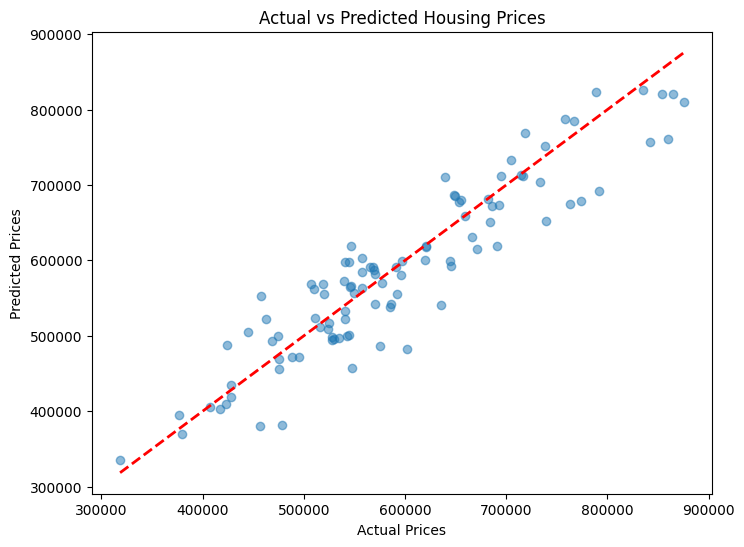

In [35]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_orig, yhat_orig, alpha=0.5)
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()],
         'r--', lw=2)  # perfect prediction line
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Housing Prices")
plt.show()
